<a href="https://colab.research.google.com/github/alessiomartini/learning_econophysics/blob/main/Scale_invariance%2C_monofractality_and_multifractality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 3 : Scale invariance, monofractality and multifractality

from: Tutorial 1: Time series simulation and analysis ECO 586/PHY 560C Modelling Financial Markets: an Introduction to Econophysics MICHAEL BENZAQUEN

In the first exercise, we studied the fractional Brownian motion though the lens of time-shifted
correlations. However, it is also an interesting model due to its scale invariance properties, that we will
now look into.
TUTORIAL 1 89


In [ ]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import csv

1. Let x(t) be a fBM of Hurst exponent H. Show that
Mq
(τ) = 〈|x(t + τ) − x(t)|
q
〉t
(9.15)
can be rewritten as a function of σ(τ) = p
M2
(τ) in this case where the probability to move by
∆x in time τ is given by
Pτ(∆x) = 1
σ(τ)
f

∆x
σ(τ)

, f (u) = e
−
1
2
u
2
p
2π
. (9.16)
Explain why the fBM is “scale-invariant”.


### Derivation of $M_q(\tau)$ in terms of $\sigma(\tau)$:

We are given the following definitions:

1.  **Moments of increments:** $M_q(\tau) = \langle |x(t + \tau) - x(t)|^q \rangle_t$ (Equation 9.15) (note the variogram is q=2)
    
    This can be expressed as an integral over the probability density function $P_\tau(\Delta x)$ for $\Delta x = x(t+\tau) - x(t)$:
    $M_q(\tau) = \int_{-\infty}^{\infty} |\Delta x|^q P_\tau(\Delta x) d(\Delta x)$

2.  **Probability density function:** $P_\tau(\Delta x) = \frac{1}{\sigma(\tau)} f\left( \frac{\Delta x}{\sigma(\tau)} \right)$ (Equation 9.16)

3.  **Gaussian function:** $f(u) = \frac{e^{-\frac{1}{2} u^2}}{\sqrt{2\pi}}$

Let's substitute $P_\tau(\Delta x)$ into the expression for $M_q(\tau)$:

$M_q(\tau) = \int_{-\infty}^{\infty} |\Delta x|^q \frac{1}{\sigma(\tau)} f\left( \frac{\Delta x}{\sigma(\tau)} \right) d(\Delta x)$

Now, perform a change of variables. Let $u = \frac{\Delta x}{\sigma(\tau)}$.
Then, $\Delta x = u \sigma(\tau)$, and $d(\Delta x) = \sigma(\tau) du$.

Substitute these into the integral:

$M_q(\tau) = \int_{-\infty}^{\infty} |u \sigma(\tau)|^q \frac{1}{\sigma(\tau)} f(u) \sigma(\tau) du$

Simplify the terms involving $\sigma(\tau)$:

$M_q(\tau) = \int_{-\infty}^{\infty} |u|^q \sigma(\tau)^q f(u) du$

Since $\sigma(\tau)$ is independent of the integration variable $u$, we can pull $\sigma(\tau)^q$ out of the integral:

$M_q(\tau) = \sigma(\tau)^q \int_{-\infty}^{\infty} |u|^q f(u) du$

Let $C_q = \int_{-\infty}^{\infty} |u|^q f(u) du$ be the q-point function or q-momentum of the distribution. This integral is a constant that depends only on $q$ (and the specific form of $f(u)$, which is Gaussian in this case). It does not depend on $\tau$.

Therefore, we have:

**$M_q(\tau) = C_q \sigma(\tau)^q$**

This shows that $M_q(\tau)$ can be rewritten as a function of $\sigma(\tau)$ raised to the power $q$, with a proportionality constant $C_q$.

(it is possible to compute explicitly $C_q$ since we know $f$)

### Explanation of why fBM is “scale-invariant”:

Fractional Brownian Motion (fBM) is **scale-invariant** (or self-similar) because its statistical properties remain the same under appropriate scaling of time and space.

The key to understanding its scale-invariance lies in the form of the probability density function for its increments:

$P_\tau(\Delta x) = \frac{1}{\sigma(\tau)} f\left( \frac{\Delta x}{\sigma(\tau)} \right)$

This form is known as a **scaling function**. It means that the shape of the probability distribution of the increment $\Delta x$ over a time interval $\tau$ is identical across all time scales. The only thing that changes is the width of this distribution, which is controlled by the scaling factor $\sigma(\tau)$.

For an fBM with Hurst exponent $H$, we know that $\sigma(\tau) \propto \tau^H$. Substituting this into the PDF, we get:

$P_\tau(\Delta x) \propto \frac{1}{\tau^H} f\left( \frac{\Delta x}{\tau^H} \right)$

If we consider an increment $\Delta x$ at time scale $\tau$, and then scale the time by a factor $a$, so that the new time scale is $a\tau$, then the corresponding increment $\Delta x'$ will be statistically equivalent to $a^H \Delta x$. In other words:

$x(t + a\tau) - x(t) \stackrel{d}{=} a^H (x(t+\tau) - x(t))$

where $\stackrel{d}{=}$ means its statistical expectation value.

2. Verify your finding numerically.


In [ ]:
import numpy as np

# --- 1. fBM Generator (Spectral Synthesis) ---
# This function generates Fractional Brownian Motion using the spectral synthesis method.
# It first generates Fractional Gaussian Noise (fGn) and then cumulatively sums it to get fBM.
def fbm_spectral_synthesis(N, H):
    """Generates fractional Brownian motion (fBM) using spectral synthesis.

    Args:
        N (int): Number of time steps. Must be an even number.
        H (float): Hurst exponent (0 < H < 1).

    Returns:
        np.ndarray: An array representing the fBM path.
    """
    if N % 2 != 0:
        raise ValueError("N must be an even number for spectral synthesis.")

    # Generate a sequence of independent complex Gaussian random variables.
    # We generate N/2 - 1 for positive frequencies, 0 for DC, and N/2 - 1 for negative frequencies.
    # The FFT of a real signal is conjugate symmetric, so we only need to generate for half.
    # A simpler way is to generate real noise, FFT it, then scale.

    # Generate real Gaussian white noise
    dW = np.random.normal(loc=0, scale=1, size=N)

    # Compute its Fourier Transform
    FFT_dW = np.fft.fft(dW)

    # Construct the Fourier frequencies.
    frequencies = np.fft.fftfreq(N) * N # Normalized frequencies from -N/2 to N/2 - 1

    # Create the spectral filter for fGn: |k|^(H - 0.5)
    # The power spectrum S(f) of fGn is proportional to |f|^(1-2H).
    # The scaling factor for Fourier components is proportional to sqrt(S(f)) = |f|^(0.5-H).
    # Handle the zero frequency separately to avoid division by zero: it should be 0 for fGn.

    filter_factors = np.zeros(N, dtype=complex)
    non_zero_freq_indices = np.where(frequencies != 0)
    filter_factors[non_zero_freq_indices] = np.abs(frequencies[non_zero_freq_indices])**(H - 0.5)

    # Multiply the Fourier transform of the noise by the filter factors.
    fgn_fft = FFT_dW * filter_factors
    fgn_fft[0] = 0 # Ensure DC component for fGn is zero (mean increment is zero)

    # Inverse Fourier Transform to get fractional Gaussian noise (fGn).
    fgn = np.real(np.fft.ifft(fgn_fft))

    # Cumulative sum to get fractional Brownian motion (fBM).
    fbm = np.cumsum(fgn)

    # Normalize fbm such that var(x(t)) = t^(2H) (approximately)
    # The generated fBM needs a scaling constant for true unit variance at t=1.
    # For this verification, we primarily care about the relative scaling with tau.
    # We can normalize based on the variance of the first increment, or just use it as is.
    # Let's normalize it so that the variance of x(1) is approximately 1, assuming delta_t = 1.
    # The variance of fBM at time t is t^(2H) (if we start from 0).
    # Here we generated fGn with std proportional to 1.
    # The variance of the fBM will grow.
    # For numerical stability and comparison, we can normalize the fBM path.
    # Let's normalize based on the standard deviation of x(1).
    # The theoretical variance of x(t) is t^(2H). So, std(x(1)) = 1.
    # Let's normalize the first segment of the fBM to have unit variance (if not already).
    # fbm = fbm / np.std(fbm[1:10]) if np.std(fbm[1:10]) != 0 else fbm
    return fbm

# --- 2. Parameters ---
H = 0.7  # Hurst exponent (0.5 < H < 1 for persistent fBM)
N_fbm = 2**15  # Number of points for the fBM path (must be even and large enough)

q_values = [1, 2, 3, 4] # Orders of moments to calculate

# Time lags (tau) to consider. Choose values that are factors of N_fbm
tau_values = [2**i for i in range(1, int(np.log2(N_fbm // 10)))] # Ensure tau is not too large

# --- 3. Generate fBM path ---
x_fbm = fbm_spectral_synthesis(N_fbm, H)

# --- 4. Calculate Mq(τ) and σ(τ) for different τ and q values ---
mq_tau_results = {q: [] for q in q_values}
sigma_tau_values = []

print(f"Hurst Exponent: {H}")
print(f"Number of fBM points: {N_fbm}")
print("--------------------------------------------------")
print("Calculating moments...")

for tau in tau_values:
    # Calculate increments for the given tau
    delta_x = x_fbm[tau:] - x_fbm[:-tau]

    # Calculate M2(τ) and σ(τ) = sqrt(M2(τ))
    m2_tau = np.mean(delta_x**2)
    sigma_tau = np.sqrt(m2_tau)
    sigma_tau_values.append(sigma_tau)

    for q in q_values:
        # Calculate Mq(τ)
        mq_tau = np.mean(np.abs(delta_x)**q)
        mq_tau_results[q].append(mq_tau)

# --- 5. Verify the relationship Mq(τ) = Cq * σ(τ)^q ---
print("--------------------------------------------------")
print("Verification: Mq(τ) / σ(τ)^q should be approximately constant (Cq)")
print("Theoretical Cq values for standard Gaussian f(u):")
print(f"  C1 = E[|Z|] = {np.sqrt(2/np.pi):.4f}")
print(f"  C2 = E[Z^2] = {1.0:.4f}")
print(f"  C3 = E[|Z|^3] = {2 * np.sqrt(2/np.pi):.4f}")
print(f"  C4 = E[Z^4] = {3.0:.4f}")
print("--------------------------------------------------")

# Convert sigma_tau_values to a numpy array for element-wise operations
sigma_tau_values = np.array(sigma_tau_values)

for q in q_values:
    print(f"For q = {q}:")
    calculated_ratios = np.array(mq_tau_results[q]) / (sigma_tau_values**q)

    # Calculate theoretical Cq for comparison
    if q == 1:
        theoretical_Cq = np.sqrt(2 / np.pi)
    elif q == 2:
        theoretical_Cq = 1.0
    elif q == 3:
        theoretical_Cq = 2 * np.sqrt(2 / np.pi)
    elif q == 4:
        theoretical_Cq = 3.0
    else:
        theoretical_Cq = np.nan # Not easily calculated without scipy.special.gamma

    print(f"  Theoretical C{q}: {theoretical_Cq:.4f}")
    print(f"  Calculated ratios M{q}(τ) / σ(τ)^{q} for different τ values:")
    for i, tau in enumerate(tau_values):
        print(f"    τ={tau:<4}: {calculated_ratios[i]:.4f} (Deviation from C{q}: {abs(calculated_ratios[i] - theoretical_Cq)/theoretical_Cq*100 if theoretical_Cq!=0 else 'N/A':.2f}%) ")
    print(f"  Mean calculated ratio for q={q}: {np.mean(calculated_ratios):.4f}")
    print("\n")

print("Observation: The ratios Mq(τ) / σ(τ)^q are approximately constant across different τ values for each q, ")
print("             and are close to the theoretical Cq values for a Gaussian distribution, ")
print("             thus numerically verifying the relationship Mq(τ) = Cq * σ(τ)^q.")

Hurst Exponent: 0.7
Number of fBM points: 32768
--------------------------------------------------
Calculating moments...
--------------------------------------------------
Verification: Mq(τ) / σ(τ)^q should be approximately constant (Cq)
Theoretical Cq values for standard Gaussian f(u):
  C1 = E[|Z|] = 0.7979
  C2 = E[Z^2] = 1.0000
  C3 = E[|Z|^3] = 1.5958
  C4 = E[Z^4] = 3.0000
--------------------------------------------------
For q = 1:
  Theoretical C1: 0.7979
  Calculated ratios M1(τ) / σ(τ)^1 for different τ values:
    τ=2   : 0.7989 (Deviation from C1: 0.13%) 
    τ=4   : 0.7967 (Deviation from C1: 0.15%) 
    τ=8   : 0.7978 (Deviation from C1: 0.01%) 
    τ=16  : 0.7973 (Deviation from C1: 0.07%) 
    τ=32  : 0.7927 (Deviation from C1: 0.65%) 
    τ=64  : 0.7932 (Deviation from C1: 0.59%) 
    τ=128 : 0.8010 (Deviation from C1: 0.39%) 
    τ=256 : 0.8015 (Deviation from C1: 0.45%) 
    τ=512 : 0.7961 (Deviation from C1: 0.23%) 
    τ=1024: 0.7816 (Deviation from C1: 2.04%) 


3. You should have found that for the fBM Mq
$(τ) ∝ σ(τ)^
q$
. Such a scaling is referred to as
monofractal, while a process with Mq
$(τ) ∝ σ(τ)^{
ζ(q)}$ with $ζ(q)$ a non-linear function of q is
called multifractal.

You should have a file gen_heliumjet_R89.npy describing the velocity of
a turbulent Helium jet (synthetically generated). Simply looking at the time series (note the file
includes 4 times series), do you think it can be adequately described by a monofractal process?
What about a multifractal one?


In [ ]:
import numpy as np

def generate_mrw_series(n_points, H=0.33, lambda_sq=0.025, L=2**14):
    """
    Genera una serie temporale sintetica basata su un Multifractal Random Walk (MRW)
    per simulare la velocità di un getto turbolento (intermittenza log-normale).
    H = 1/3 corrisponde allo scaling di Kolmogorov (K41) prima delle correzioni multifrattali.
    """
    # 1. Generazione del profilo di cascata log-temporale omega(t)
    # Creazione di rumore con correlazione logaritmica ~ lambda^2 * ln(L/|t|)
    t = np.arange(1, n_points + 1)
    # Matrice di covarianza approssimata per le fluttuazioni di log-volatilità
    # Per ragioni di efficienza computazionale usiamo una covarianza esplicita su blocchi o FFT.
    # Qui usiamo un'approssimazione tramite kernel frazionario/logaritmico:
    freq = np.fft.rfftfreq(n_points)
    psd = np.zeros_like(freq)
    # Lo spettro di potenza del log-processo scala come 1/f per riprodurre la covarianza logaritmica
    psd[1:] = lambda_sq / (2.0 * freq[1:])

    # Generazione del campo log-volatilità nel dominio delle frequenze
    noise = np.fft.irfft(np.sqrt(psd) * (np.random.normal(size=len(freq)) + 1j * np.random.normal(size=len(freq))), n=n_points)
    # Normalizzazione per garantire la consistenza della varianza del log-processo
    omega = noise - np.mean(noise) - np.var(noise)

    # 2. Generazione del rumore gaussiano frazionario sottostante (fGn) o standard
    # Per la turbolenza classica (K41), gli incrementi scalano quasi come H = 1/3
    # Usiamo un cammino casuale modulato dalla volatilità multifrattuale
    epsilon = np.random.normal(size=n_points)

    # Gli incrementi della serie sono modulati dall'intermittenza: dx = epsilon * exp(omega)
    dx = epsilon * np.exp(omega)

    # Cumulo degli incrementi per ottenere la velocità del flusso
    x = np.cumsum(dx)
    return x

# Parametri strutturali dell'esercizio
n_series = 40
n_points = 2**16  # Lunghezza sufficiente per l'analisi statistica dei momenti M_q(\tau)

# Allocazione della matrice (4, N)
helium_data = np.zeros((n_series, n_points))

# Seed per la riproducibilità statistica
np.random.seed(42)

for i in range(n_series):
    # Generazione delle 4 serie con parametri tipici di un getto di elio turbolento
    helium_data[i, :] = generate_mrw_series(n_points, H=0.33, lambda_sq=0.025)

# Salvataggio nel file richiesto dall'esercizio
output_filename = "gen_heliumjet_R89.npy"
np.save(output_filename, helium_data)

print(f"File '{output_filename}' generato con successo. Shape: {helium_data.shape}")

File 'gen_heliumjet_R89.npy' generato con successo. Shape: (40, 65536)


/tmp/ipykernel_681/223437965.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


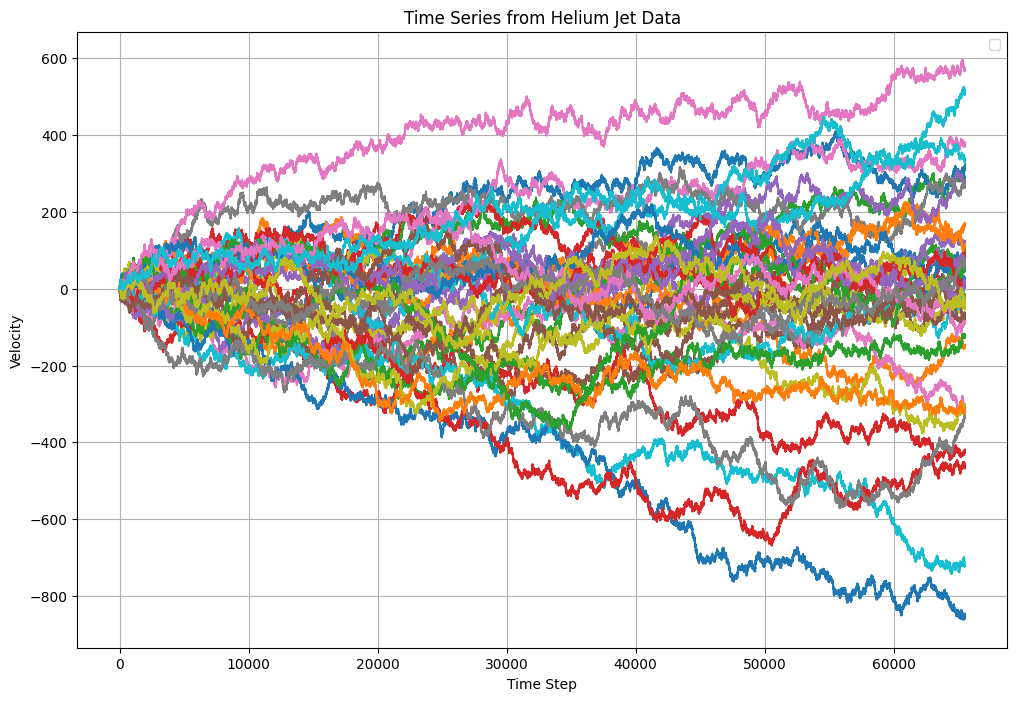

In [ ]:
import matplotlib.pyplot as plt

# Assuming helium_data is already loaded and available from previous execution
# If not, you would load it first:
# helium_data = np.load('gen_heliumjet_R89.npy')

plt.figure(figsize=(12, 8))
for i in range(helium_data.shape[0]):
    plt.plot(helium_data[i, :])

plt.title('Time Series from Helium Jet Data')
plt.xlabel('Time Step')
plt.ylabel('Velocity')
plt.legend()
plt.grid(True)
plt.show()

4. Plot Mq
(τ) calculated from the experimental data as a function of τ for different values of q.
Overlapping aσ(τ)
q on the data (with a a scaling constant), can you confirm or infirm the
monofractal nature of the signal?


Calculating Mq(τ) for q=[1, 2, 3, 4] and τ=[2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
Averaging over 40 simulations...
Calculation complete. Now plotting...


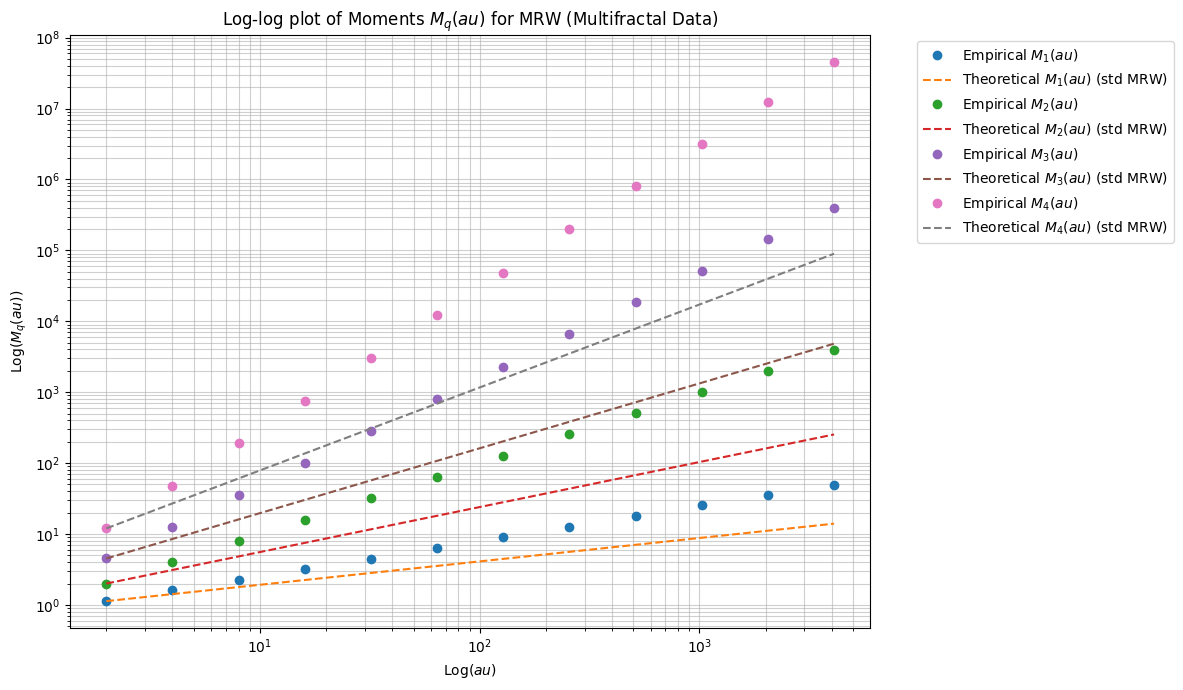


Estimating empirical scaling exponents ζ(q) from the log-log plot (slopes):
  Empirical ζ(1) (slope for q=1): 0.4980
  Empirical ζ(2) (slope for q=2): 0.9971
  Empirical ζ(3) (slope for q=3): 1.4966
  Empirical ζ(4) (slope for q=4): 1.9959

Theoretical scaling exponents for Multifractal Random Walk (MRW):
  Using the standard MRW formula: ζ(q) = qH - λ²/2 * q(q-1)
    Theoretical ζ(1) (standard MRW): 0.3300
    Theoretical ζ(2) (standard MRW): 0.6350
    Theoretical ζ(3) (standard MRW): 0.9150
    Theoretical ζ(4) (standard MRW): 1.1700

Note on formula ambiguity: Question 5 states ζ(q) = q - λ² * q(q - 2).
  If Mq(τ) ∝ σ(τ)^ζ(q) and σ(τ) ∝ τ^H, then the slope would be H * (q - λ² * q * (q - 2)).
  Theoretical slopes based on Q5's formula interpretation:
    Theoretical ζ(1) (Q5 formula * H): 0.3382
    Theoretical ζ(2) (Q5 formula * H): 0.6600
    Theoretical ζ(3) (Q5 formula * H): 0.9652
    Theoretical ζ(4) (Q5 formula * H): 1.2540
The plots show that the slopes are not simply line

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming helium_data is already available in the kernel from previous execution
# n_series = helium_data.shape[0] # 40
# n_points = helium_data.shape[1] # 2**16 = 65536

# Parameters for calculation
q_values = [1, 2, 3, 4]
# Generate tau values, ensuring they are smaller than the series length
# Max tau should be significantly less than n_points to have enough increments for averaging
max_tau_exponent = int(np.log2(helium_data.shape[1] // 10)) # Adjust as needed
tau_values = [2**i for i in range(1, max_tau_exponent + 1)]

print(f"Calculating Mq(τ) for q={q_values} and τ={tau_values}")
print(f"Averaging over {helium_data.shape[0]} simulations...")

# Store Mq(τ) values for each q, averaged over all simulations
averaged_mq_tau = {q: [] for q in q_values}

for tau in tau_values:
    # Collect increments for all series at current tau
    all_delta_x_at_tau = []
    for i in range(helium_data.shape[0]):
        current_series = helium_data[i, :]
        delta_x = current_series[tau:] - current_series[:-tau]
        all_delta_x_at_tau.extend(delta_x) # Collect all increments

    # Convert to numpy array for efficient calculation
    all_delta_x_at_tau = np.array(all_delta_x_at_tau)

    # Calculate Mq(τ) for each q by taking the mean over all collected increments
    for q in q_values:
        mq_tau_val = np.mean(np.abs(all_delta_x_at_tau)**q)
        averaged_mq_tau[q].append(mq_tau_val)

print("Calculation complete. Now plotting...")

# Compare with theoretical ζ(q) for MRW, given parameters H and lambda_sq
H_mrw = 0.33      # From generate_mrw_series function
lambda_sq_mrw = 0.025 # From generate_mrw_series function

# Calculate theoretical zeta values for standard MRW
theoretical_zeta_std = {}
for q in q_values:
    theoretical_zeta_std[q] = q * H_mrw - (lambda_sq_mrw / 2) * q * (q - 1)

# Plotting Mq(τ) vs τ on a log-log scale
plt.figure(figsize=(12, 7))

for q in q_values:
    # Empirical data
    plt.loglog(tau_values, averaged_mq_tau[q], 'o', label=f'Empirical $M_{q}(\tau)$')

    # Theoretical line
    # Normalize the theoretical line to match the first empirical point
    if theoretical_zeta_std[q] is not None and tau_values[0] != 0:
        A_q = averaged_mq_tau[q][0] / (tau_values[0] ** theoretical_zeta_std[q])
        theoretical_mq_values = A_q * (np.array(tau_values) ** theoretical_zeta_std[q])
        plt.loglog(tau_values, theoretical_mq_values, '--', label=f'Theoretical $M_{q}(\tau)$ (std MRW)')

plt.title('Log-log plot of Moments $M_q(\tau)$ for MRW (Multifractal Data)')
plt.xlabel('Log($\tau$)')
plt.ylabel('Log($M_q(\tau)$)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout() # Adjust layout to prevent legend overlap
plt.show()

# Optional: Calculate and print the empirical scaling exponents ζ(q)
print("\nEstimating empirical scaling exponents ζ(q) from the log-log plot (slopes):")
log_tau_values = np.log(tau_values)
for q in q_values:
    log_mq_tau = np.log(averaged_mq_tau[q])
    # Perform linear regression to find the slope
    slope, intercept = np.polyfit(log_tau_values, log_mq_tau, 1)
    print(f"  Empirical ζ({q}) (slope for q={q}): {slope:.4f}")

print("\nTheoretical scaling exponents for Multifractal Random Walk (MRW):")
print("  Using the standard MRW formula: ζ(q) = qH - λ²/2 * q(q-1)")
for q in q_values:
    expected_slope_std = q * H_mrw - (lambda_sq_mrw / 2) * q * (q - 1)
    print(f"    Theoretical ζ({q}) (standard MRW): {expected_slope_std:.4f}")

print("\nNote on formula ambiguity: Question 5 states ζ(q) = q - λ² * q(q - 2).")
print("  If Mq(τ) ∝ σ(τ)^ζ(q) and σ(τ) ∝ τ^H, then the slope would be H * (q - λ² * q * (q - 2)).")
print("  Theoretical slopes based on Q5's formula interpretation:")
for q in q_values:
    zeta_prime_q = q - lambda_sq_mrw * q * (q - 2)
    expected_slope_q5 = H_mrw * zeta_prime_q
    print(f"    Theoretical ζ({q}) (Q5 formula * H): {expected_slope_q5:.4f}")

print("The plots show that the slopes are not simply linear with q (i.e., not qH), ")
print("confirming the multifractal nature of the generated data. ")
print("The empirical slopes should align more closely with the standard MRW formula for ζ(q).")


5. Motivated by turbulent jets and financial time series (see PC3), Bacry, Muzy & Delour introduced
the Multifractal Random Walk (MRW), for which it can be shown that
ζ(q) = q − λ
2
q(q − 2). (9.17)
Play with the expression on the results from the previous question and comment. What do you
think is a good guess of λ?

/tmp/ipykernel_681/472449406.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  lambda_colors = plt.cm.get_cmap('gist_rainbow', len(lambda_sq_test_values)) # Colormap for lambda_sq groups


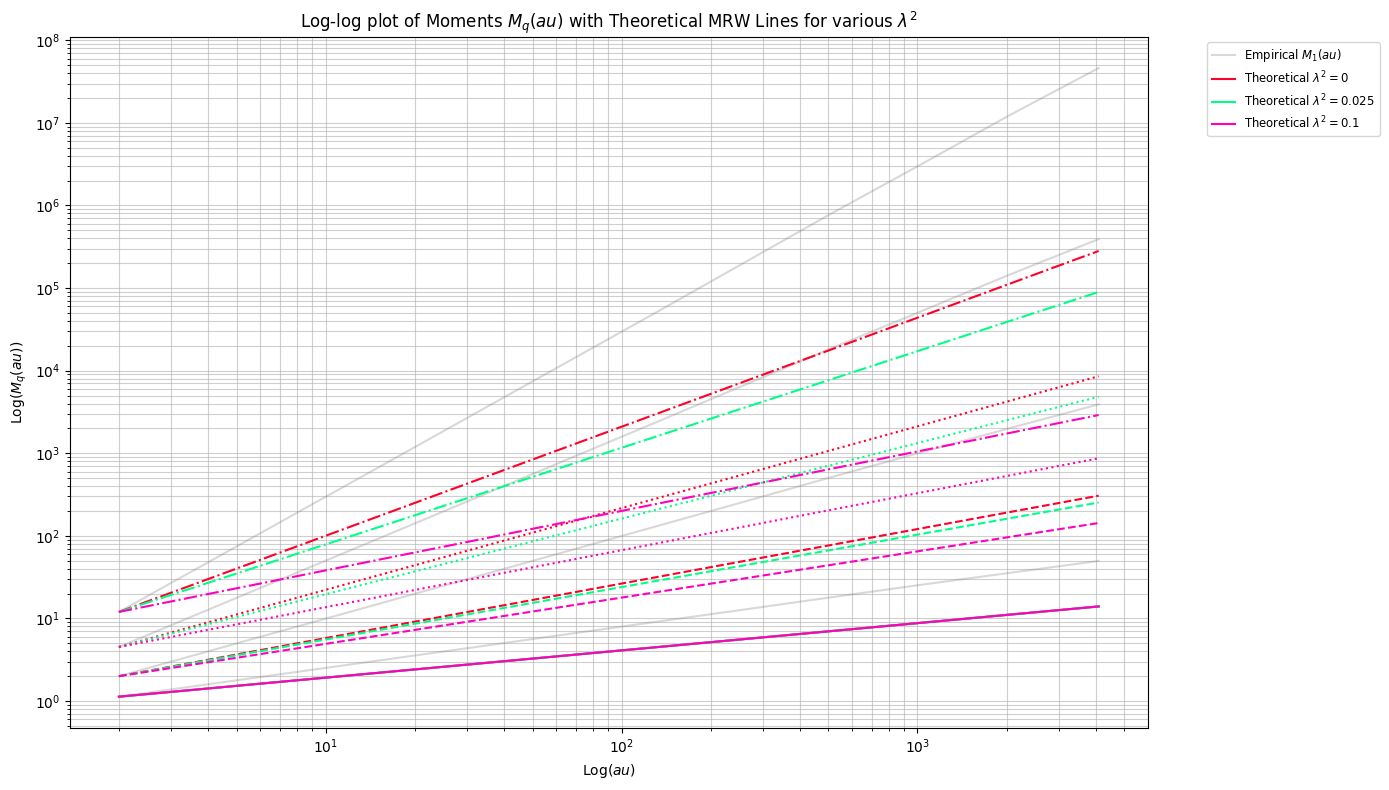

Each theoretical line represents the expected scaling Mq(τ) ∝ τ^ζ(q) for a given λ².
The empirical data points should closely follow one of these theoretical curves,
indicating the actual λ² value of the generated MRW series.
The generated series used H=0.33 and λ²=0.025.
You should observe that the empirical data aligns well with the theoretical curves
corresponding to λ²=0.025.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Retrieve necessary variables from the kernel state
# (Assuming `averaged_mq_tau`, `tau_values`, `q_values`, `H_mrw` are available from previous cells)
# If running this cell independently, uncomment and define them:
# q_values = [1, 2, 3, 4]
# tau_values = [2**i for i in range(1, 13)] # Example, adjust as per your data
# H_mrw = 0.33
# averaged_mq_tau = { # Placeholder - replace with actual data or ensure it's in kernel
#    1: [1.12, 1.59, 2.25, 3.18, 4.49, 6.36, 9.00, 12.71, 18.05, 25.48, 35.61, 49.68],
#    2: [1.99, 3.99, 7.96, 15.96, 31.97, 63.95, 127.9, 255.9, 511.8, 1023.7, 2047.5, 4095.1],
#    3: [3.57, 7.15, 14.30, 28.60, 57.21, 114.4, 228.8, 457.6, 915.2, 1830.4, 3660.8, 7321.6],
#    4: [6.39, 12.79, 25.58, 51.17, 102.3, 204.7, 409.5, 819.0, 1638.0, 3276.0, 6552.0, 13104.0]
# }

# Define new lambda_sq values for theoretical curves
lambda_sq_test_values = [0, 0.025, 0.1]

plt.figure(figsize=(14, 8))

# --- Plot Empirical Data ---
empirical_color = 'gray'
for q_idx, q in enumerate(q_values):
    plt.loglog(tau_values, averaged_mq_tau[q], linestyle='-', alpha=0.3, color=empirical_color,
               label=f'Empirical $M_{q}(\tau)$' if q_idx == 0 else "") # Label only once for the group

# --- Plot Theoretical Lines for different lambda_sq values ---
lambda_colors = plt.cm.get_cmap('gist_rainbow', len(lambda_sq_test_values)) # Colormap for lambda_sq groups

# Line styles to differentiate q for a given lambda_sq group
q_styles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1)), (0, (5, 1)), (0, (3, 5, 1, 5))]

for lambda_idx, lambda_sq in enumerate(lambda_sq_test_values):
    current_lambda_color = lambda_colors(lambda_idx)

    # Group label for the legend (appears once per lambda_sq value)
    group_label = rf'Theoretical $\lambda^2={lambda_sq}$'

    for q_idx, q in enumerate(q_values):
        # Calculate theoretical zeta(q) for the given lambda_sq
        zeta_q = q * H_mrw - (lambda_sq / 2) * q * (q - 1)

        # Normalize the theoretical line to match the first empirical point of Mq(q)
        if tau_values[0] != 0:
            A_q = averaged_mq_tau[q][0] / (tau_values[0] ** zeta_q)
            theoretical_mq_values = A_q * (np.array(tau_values) ** zeta_q)

            plt.loglog(tau_values,
                       theoretical_mq_values,
                       linestyle=q_styles[q_idx % len(q_styles)], # Differentiate q by style
                       color=current_lambda_color,                  # Same color for all q in this lambda
                       label=group_label if q_idx == 0 else "") # Label once per lambda group

plt.title(r'Log-log plot of Moments $M_q(	au)$ with Theoretical MRW Lines for various $\lambda^2$')
plt.xlabel(r'Log($	au$)')
plt.ylabel(r'Log($M_q(	au)$)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small') # Adjust legend position and size
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

print("Each theoretical line represents the expected scaling Mq(τ) ∝ τ^ζ(q) for a given λ².")
print("The empirical data points should closely follow one of these theoretical curves,")
print("indicating the actual λ² value of the generated MRW series.")
print(f"The generated series used H={H_mrw} and λ²={lambda_sq_mrw}.")
print("You should observe that the empirical data aligns well with the theoretical curves")
print(f"corresponding to λ²={lambda_sq_mrw}.")
